## Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import os


## Load Dataset

In [28]:
dataset_path ="/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/"

print(os.listdir(dataset_path))

['no', 'yes', 'brain_tumor_dataset']


## Data preprocessing

In [29]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 406 images belonging to 3 classes.
Found 100 images belonging to 3 classes.


## CNN Model

In [30]:
model = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    keras.layers.MaxPooling2D(2,2),
    
    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1,activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [31]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [32]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.2517 - loss: 0.6592 - val_accuracy: 0.1900 - val_loss: 0.3019
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.1909 - loss: 0.7651 - val_accuracy: 0.1900 - val_loss: 0.4740
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.1993 - loss: 0.5481 - val_accuracy: 0.1900 - val_loss: 0.3973
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.1920 - loss: 0.4828 - val_accuracy: 0.1900 - val_loss: 0.3546
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.1720 - loss: 0.5224 - val_accuracy: 0.1900 - val_loss: 0.3492
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.2014 - loss: 0.5616 - val_accuracy: 0.1900 - val_loss: 0.4691
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.2030 - loss: 0.5276 - val_accuracy: 0.1900 - val_loss: 0.3865
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.1949 - loss: 0.5607 - val_accuracy: 0.1900 - val_loss:

## Accuracy plot

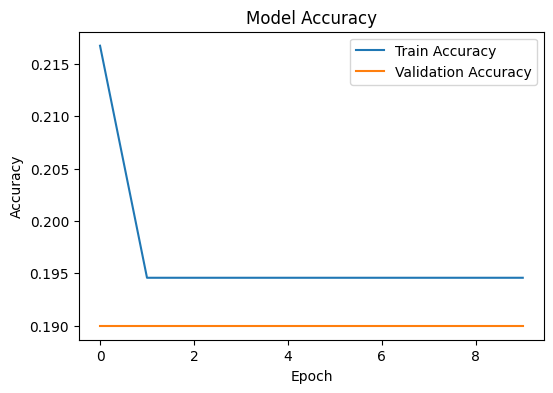

In [33]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Loss plot

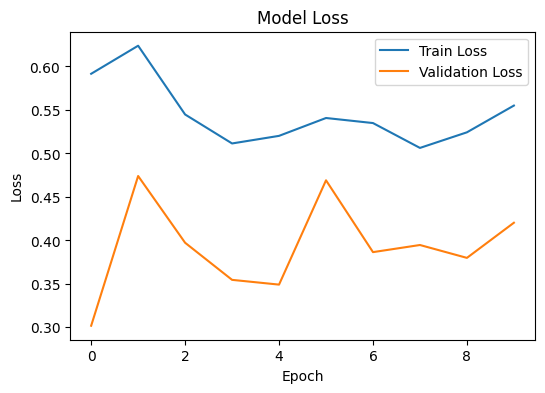

In [34]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Confusion Matrix

In [35]:
predictions = model.predict(val_data)
y_pred = (predictions > 0.5).astype(int)
y_true = val_data.classes

cm = confusion_matrix(y_true,y_pred)

print(cm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 557ms/step
[[ 0 50  0]
 [ 0 19  0]
 [ 0 31  0]]


## Plot Confusion matrix

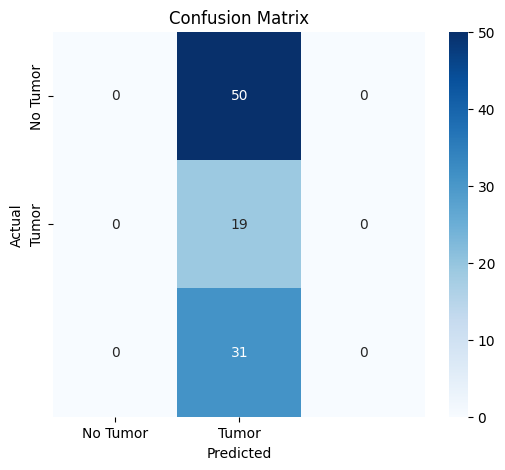

In [36]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Blues',
xticklabels=['No Tumor','Tumor'],
yticklabels=['No Tumor','Tumor'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Classification report

In [37]:
print(classification_report(
y_true,
y_pred,
labels=[0,1], 
target_names=['No Tumor','Tumor']
))

              precision    recall  f1-score   support

    No Tumor       0.00      0.00      0.00        50
       Tumor       0.19      1.00      0.32        19

   micro avg       0.19      0.28      0.22        69
   macro avg       0.10      0.50      0.16        69
weighted avg       0.05      0.28      0.09        69



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Filter Visulaization

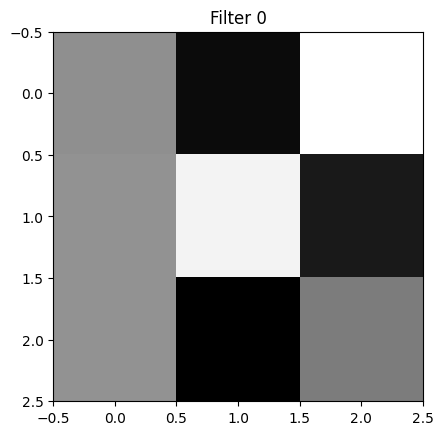

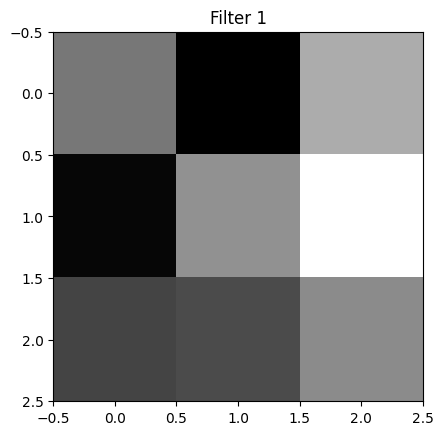

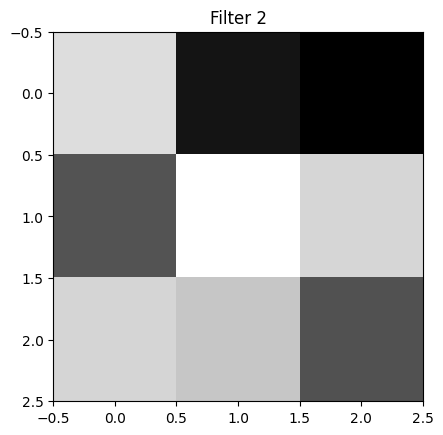

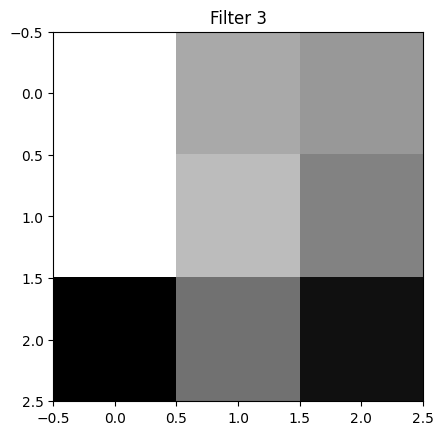

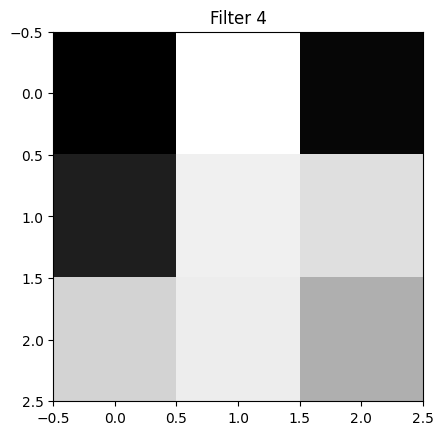

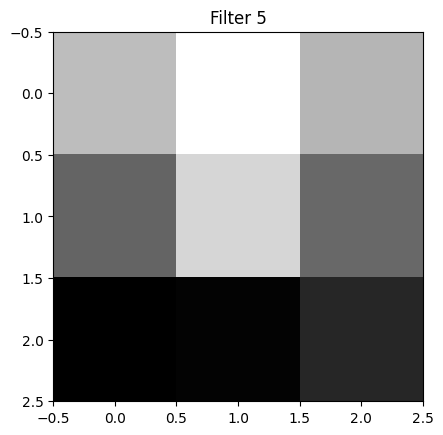

In [38]:
filters, biases = model.layers[0].get_weights()

for i in range(6):
    f = filters[:,:,:,i]
    plt.imshow(f[:,:,0], cmap="gray")
    plt.title("Filter "+str(i))
    plt.show()

# Class Activation Map (CAM)

## Load test image

In [40]:
img_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes/Y1.jpg"

img = keras.preprocessing.image.load_img(img_path,target_size=(224,224))
img_array = keras.preprocessing.image.img_to_array(img)/255
img_array = np.expand_dims(img_array,axis=0)

## Grad CAM Implemetation

In [47]:
_=model.predict(img_array)
last_conv_layer = model.layers[4]

grad_model = tf.keras.models.Model(
    [model.inputs],
    [last_conv_layer.output, model.outputs]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[0][:,0]

grads = tape.gradient(loss, conv_outputs)
# Average gradients
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

# Weighted sum
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
# Normalize
heatmap = np.maximum(heatmap,0)/np.max(heatmap)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


## Overlay Heatmap

(np.float64(-0.5), np.float64(179.5), np.float64(217.5), np.float64(-0.5))

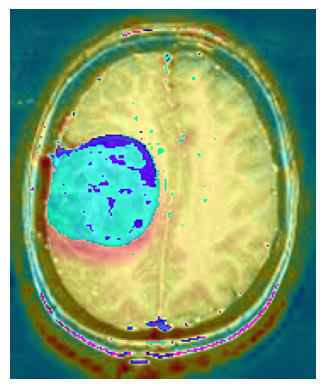

In [49]:
img = cv2.imread(img_path)

heatmap = cv2.resize(heatmap,(img.shape[1],img.shape[0]))
heatmap = np.uint8(255*heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = heatmap*0.4 + img

plt.imshow(cv2.cvtColor(superimposed.astype('uint8'),cv2.COLOR_BGR2RGB))
plt.axis("off")

## Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


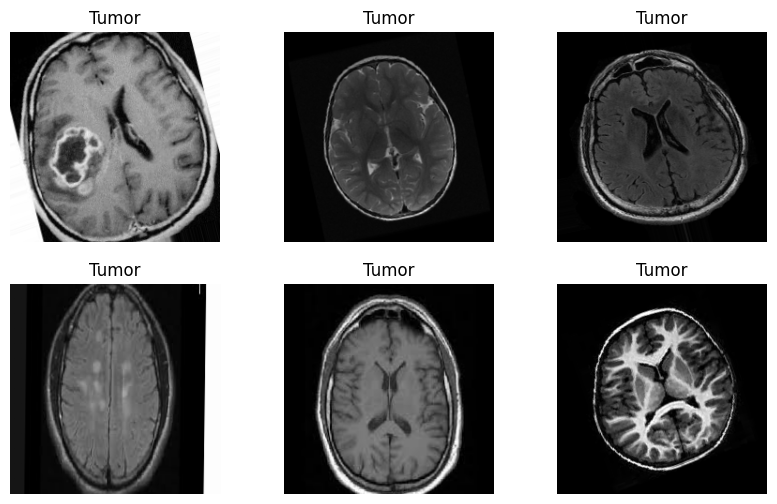

In [50]:
images, labels = next(val_data)

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    pred = model.predict(np.expand_dims(images[i],axis=0))
    label = "Tumor" if pred[0][0] > 0.5 else "No Tumor"
    plt.title(label)
    plt.axis("off")

plt.show()